In [88]:
import os
import pandas as pd
import cv2
from tqdm import tqdm
import numpy as np
import subprocess
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
vids_folder = "/Users/diogo/Desktop/video_timings"
owl_vid = os.path.join(vids_folder, 'owl.mp4')
os.path.exists(owl_vid)

True

In [3]:
df = pd.read_csv(os.path.join(vids_folder, 'frames.csv'))
df = df.iloc[1::2]

In [4]:
a = df['Unnamed: 4']

In [5]:
a[:1000]

1       0.0333333
3       0.0333333
5       0.0333333
7       0.0333333
9       0.0333333
          ...    
1991          NaN
1993          NaN
1995          NaN
1997          NaN
1999          NaN
Name: Unnamed: 4, Length: 1000, dtype: object

In [13]:
cap = cv2.VideoCapture(os.path.join(vids_folder, "webcam.mp4"))
timestamps = []
frames = []
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"FPS: {fps}, total frames: {frame_count}")

pbar = tqdm(total=frame_count)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_idx = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
    timestamp_ms = cap.get(cv2.CAP_PROP_POS_MSEC)
    timestamps.append(timestamp_ms)
    frames.append(frame_idx)
    pbar.update(1)
    # print(frame_idx, timestamp_ms / 1000)  # seconds

cap.release()


FPS: 30.0, total frames: 13959



100%|████████████████████████████████████████████████████████▊| 13911/13959 [00:23<00:00, 940.45it/s]

In [7]:
np.diff(np.array(frames)).max()

np.int64(1)

In [8]:
np.sum(np.isnan(np.array(frames)))

np.int64(0)

In [17]:
# timestamps = np.array(timestamps)
np.diff(timestamps).max()

np.float64(33.33333333337214)

In [18]:
ffprobe -select_streams v -show_frames -print_format json webcam.mp4 > frames.json

13911

In [28]:
with open((os.path.join(vids_folder, 'frames.json')), 'r') as file:
    data = json.load(file)

In [43]:
data['frames'][1000]

{'media_type': 'video',
 'stream_index': 0,
 'key_frame': 0,
 'pts': 3072716,
 'pts_time': '34.141289',
 'pkt_dts': 3072716,
 'pkt_dts_time': '34.141289',
 'best_effort_timestamp': 3072716,
 'best_effort_timestamp_time': '34.141289',
 'duration': 3000,
 'duration_time': '0.033333',
 'pkt_pos': '8917649',
 'pkt_size': '8887',
 'width': 640,
 'height': 480,
 'crop_top': 0,
 'crop_bottom': 0,
 'crop_left': 0,
 'crop_right': 0,
 'pix_fmt': 'yuv420p',
 'sample_aspect_ratio': '1:1',
 'pict_type': 'P',
 'interlaced_frame': 0,
 'top_field_first': 0,
 'repeat_pict': 0,
 'chroma_location': 'left'}

In [45]:
frames = data["frames"]  # assuming the JSON root key is 'frames'

frame_data = []
for frame in tqdm(frames):
    frame_data.append({
        "pts": frame.get("pts"),
        "pts_time": float(frame.get("pts_time", 0)),
        "pkt_dts": frame.get("pkt_dts"),
        "pkt_dts_time": float(frame.get("pkt_dts_time", 0)),
        "best_effort_timestamp": frame.get("best_effort_timestamp"),
        "best_effort_timestamp_time": float(frame.get("best_effort_timestamp_time", 0)),
        "duration": frame.get("duration"),
        "duration_time": float(frame.get("duration_time", 0)),
        "pkt_pos": frame.get("pkt_pos"),
        "pkt_size": frame.get("pkt_size"),
        "key_frame": frame.get("key_frame")
    })

df = pd.DataFrame(frame_data)


100%|██████████████████████████████████████████████████████| 13911/13911 [00:00<00:00, 367054.37it/s]


In [46]:
df

,pts,pts_time,pkt_dts,pkt_dts_time,best_effort_timestamp,best_effort_timestamp_time,duration,duration_time,pkt_pos,pkt_size,key_frame
0,72716,0.807956,72716,0.807956,72716,0.807956,3000,0.033333,18058,34184,1
1,75716,0.841289,75716,0.841289,75716,0.841289,3000,0.033333,52242,6866,0
2,78716,0.874622,78716,0.874622,78716,0.874622,3000,0.033333,59108,6149,0
3,81716,0.907956,81716,0.907956,81716,0.907956,3000,0.033333,65257,5885,0
4,84716,0.941289,84716,0.941289,84716,0.941289,3000,0.033333,71142,6848,0
...,...,...,...,...,...,...,...,...,...,...,...
13906,41790716,464.341289,41790716,464.341289,41790716,464.341289,3000,0.033333,123762124,9689,0
13907,41793716,464.374622,41793716,464.374622,41793716,464.374622,3000,0.033333,123771813,9773,0
13908,41796716,464.407956,41796716,464.407956,41796716,464.407956,3000,0.033333,123781586,6182,0
13909,41799716,464.441289,41799716,464.441289,41799716,464.441289,3000,0.033333,123787768,6418,0


In [50]:
np.diff(df.pts_time).max()

np.float64(0.033334000000024844)

In [51]:
np.diff(df.best_effort_timestamp_time).max()

np.float64(0.033334000000024844)

In [52]:
print(np.diff(df.pts_time).min())

0.033332999999970525


In [53]:
print(df[df.key_frame == 1][['pts_time', 'pkt_pos']])

         pts_time    pkt_pos
0        0.807956      18058
30       1.807956     256352
60       2.807956     522515
90       3.807956     782924
120      4.807956    1067432
...           ...        ...
13770  459.807956  122545524
13800  460.807956  122822420
13830  461.807956  123079130
13860  462.807956  123357882
13890  463.807956  123600297

[464 rows x 2 columns]


**use from here**

In [66]:
cmd = [
    "ffprobe",
    "-select_streams", "v",
    "-show_frames",
    "-print_format", "json",
    os.path.join(vids_folder, 'owl.mp4')
]

result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

# The JSON is in result.stdout
frames_data = json.loads(result.stdout)
owl_data = pd.DataFrame(frames_data['frames'])
np.diff(owl_data.pts_time.astype(float)).max()

np.float64(0.033334000000024844)

In [74]:
cmd = [
    "ffprobe",
    "-select_streams", "v",
    "-show_frames",
    "-print_format", "json",
    os.path.join(vids_folder, 'screen.mp4')
]

result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

# The JSON is in result.stdout
frames_data = json.loads(result.stdout)
screen_data = pd.DataFrame(frames_data['frames'])
np.diff(screen_data.pts_time.astype(float)).max()

np.float64(0.033334000000024844)

In [75]:
screen_data

,media_type,stream_index,key_frame,pts,pts_time,pkt_dts,pkt_dts_time,best_effort_timestamp,best_effort_timestamp_time,duration,...,crop_bottom,crop_left,crop_right,pix_fmt,sample_aspect_ratio,pict_type,interlaced_frame,top_field_first,repeat_pict,chroma_location
0,video,0,1,0,0.000000,0,0.000000,0,0.000000,3000,...,0,0,0,yuv420p,1:1,I,0,0,0,left
1,video,0,0,3000,0.033333,3000,0.033333,3000,0.033333,3000,...,0,0,0,yuv420p,1:1,P,0,0,0,left
2,video,0,0,6000,0.066667,6000,0.066667,6000,0.066667,3000,...,0,0,0,yuv420p,1:1,P,0,0,0,left
3,video,0,0,9000,0.100000,9000,0.100000,9000,0.100000,3000,...,0,0,0,yuv420p,1:1,P,0,0,0,left
4,video,0,0,12000,0.133333,12000,0.133333,12000,0.133333,3000,...,0,0,0,yuv420p,1:1,P,0,0,0,left
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13917,video,0,0,41750999,463.899989,41750999,463.899989,41750999,463.899989,3000,...,0,0,0,yuv420p,1:1,P,0,0,0,left
13918,video,0,0,41753999,463.933322,41753999,463.933322,41753999,463.933322,3000,...,0,0,0,yuv420p,1:1,P,0,0,0,left
13919,video,0,0,41756999,463.966656,41756999,463.966656,41756999,463.966656,3000,...,0,0,0,yuv420p,1:1,P,0,0,0,left
13920,video,0,1,41759999,463.999989,41759999,463.999989,41759999,463.999989,3000,...,0,0,0,yuv420p,1:1,I,0,0,0,left


In [79]:
cap = cv2.VideoCapture(os.path.join(vids_folder, 'screen.mp4'))
cap.set(cv2.CAP_PROP_POS_MSEC, 5000)
ret, frame = cap.read()
# OpenCV loads images as BGR, convert to RGB for matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
cap.release()


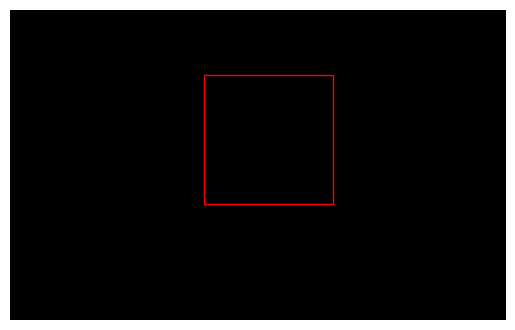

In [97]:
screenpic = plt.figure()
plt.imshow(frame_rgb)
plt.axis('off')
rectangle = patches.Rectangle((1500, 500), 1000, 1000, linewidth=1, 
                              edgecolor='r', facecolor='none')
plt.gca().add_patch(rectangle)
plt.show()

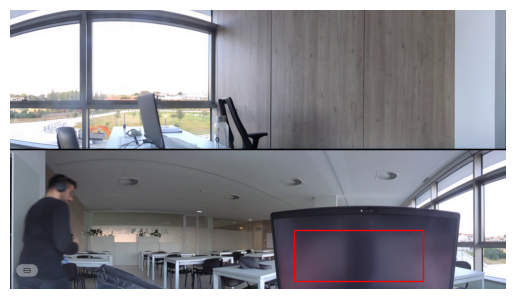

In [110]:
cap = cv2.VideoCapture(os.path.join(vids_folder, 'owl.mp4'))
cap.set(cv2.CAP_PROP_POS_MSEC, 5000)
ret, frame = cap.read()
# OpenCV loads images as BGR, convert to RGB for matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
cap.release()
owlpic = plt.figure()
plt.imshow(frame_rgb)
plt.axis('off')
rectangle = patches.Rectangle((1100, 850), 500, 200, linewidth=1, 
                              edgecolor='r', facecolor='none')
plt.gca().add_patch(rectangle)
plt.show()

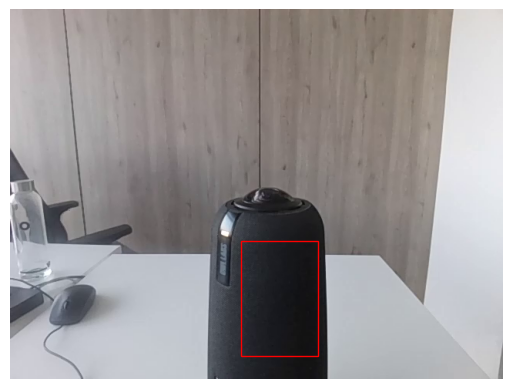

In [121]:
cap = cv2.VideoCapture(os.path.join(vids_folder, 'webcam.mp4'))
cap.set(cv2.CAP_PROP_POS_MSEC, 5000)
ret, frame = cap.read()
# OpenCV loads images as BGR, convert to RGB for matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
cap.release()
webcampic = plt.figure()
plt.imshow(frame_rgb)
plt.axis('off')
rectangle = patches.Rectangle((300, 300), 100, 150, linewidth=1, 
                              edgecolor='r', facecolor='none')
plt.gca().add_patch(rectangle)
plt.show()

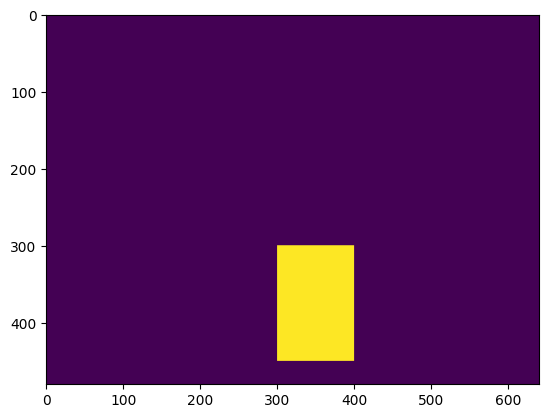

In [129]:
webcam_mask = np.zeros(frame_rgb.shape[:2], dtype=bool)
webcam_mask[300:300+150, 300:300+100] = True
plt.imshow(webcam_mask)